In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, quantitative research aesthetic
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Define target files based on your folder structure
TARGET_FPR = 0.05
N_FEATURES = 2**14

# Update these paths if your notebook is in a different relative directory
result_file = f"results/result_{TARGET_FPR}_{N_FEATURES}.csv"
baseline_file = f"results/baseline_{TARGET_FPR}_{N_FEATURES}.csv"

print(f"Targeting files:\n- {result_file}\n- {baseline_file}")

Targeting files:
- results/result_0.1_4096.csv
- results/baseline_0.1_4096.csv


In [60]:
try:
    lbf_df = pd.read_csv(result_file)
    baseline_df = pd.read_csv(baseline_file)
    print("Data loaded successfully.")
except FileNotFoundError as e:
    print(f"Error loading files: {e}")

base_latency = baseline_df["time_per_query_ns"].mean()
base_memory = baseline_df["memory_mb"].mean()
base_throughput = baseline_df["throughtput_s"].mean()

optimal_lbf = lbf_df.sort_values(
    by=["false_negative","observed_fpr","total_memory_mb","time_per_query_ns"]
).iloc[0]

print("\n--- Baseline (Standard Bloom Filter) ---")
print(f"Memory:  {base_memory:.4f} MB")
print(f"Latency: {base_latency:.2f} ns/query")

print("\n--- Optimal Learned Bloom Filter ---")
print(f"Threshold: {optimal_lbf['threshold']}")
print(f"Memory:    {optimal_lbf['total_memory_mb']:.4f} MB")
print(f"Latency:   {optimal_lbf['time_per_query_ns']:.2f} ns/query")
print(f"FPR:       {optimal_lbf['observed_fpr']:.6f}")
print(f"FN:        {int(optimal_lbf['false_negative'])}")

Data loaded successfully.

--- Baseline (Standard Bloom Filter) ---
Memory:  0.1314 MB
Latency: 39.11 ns/query

--- Optimal Learned Bloom Filter ---
Threshold: 0.925
Memory:    0.0590 MB
Latency:   653.72 ns/query
FPR:       0.099822
FN:        0


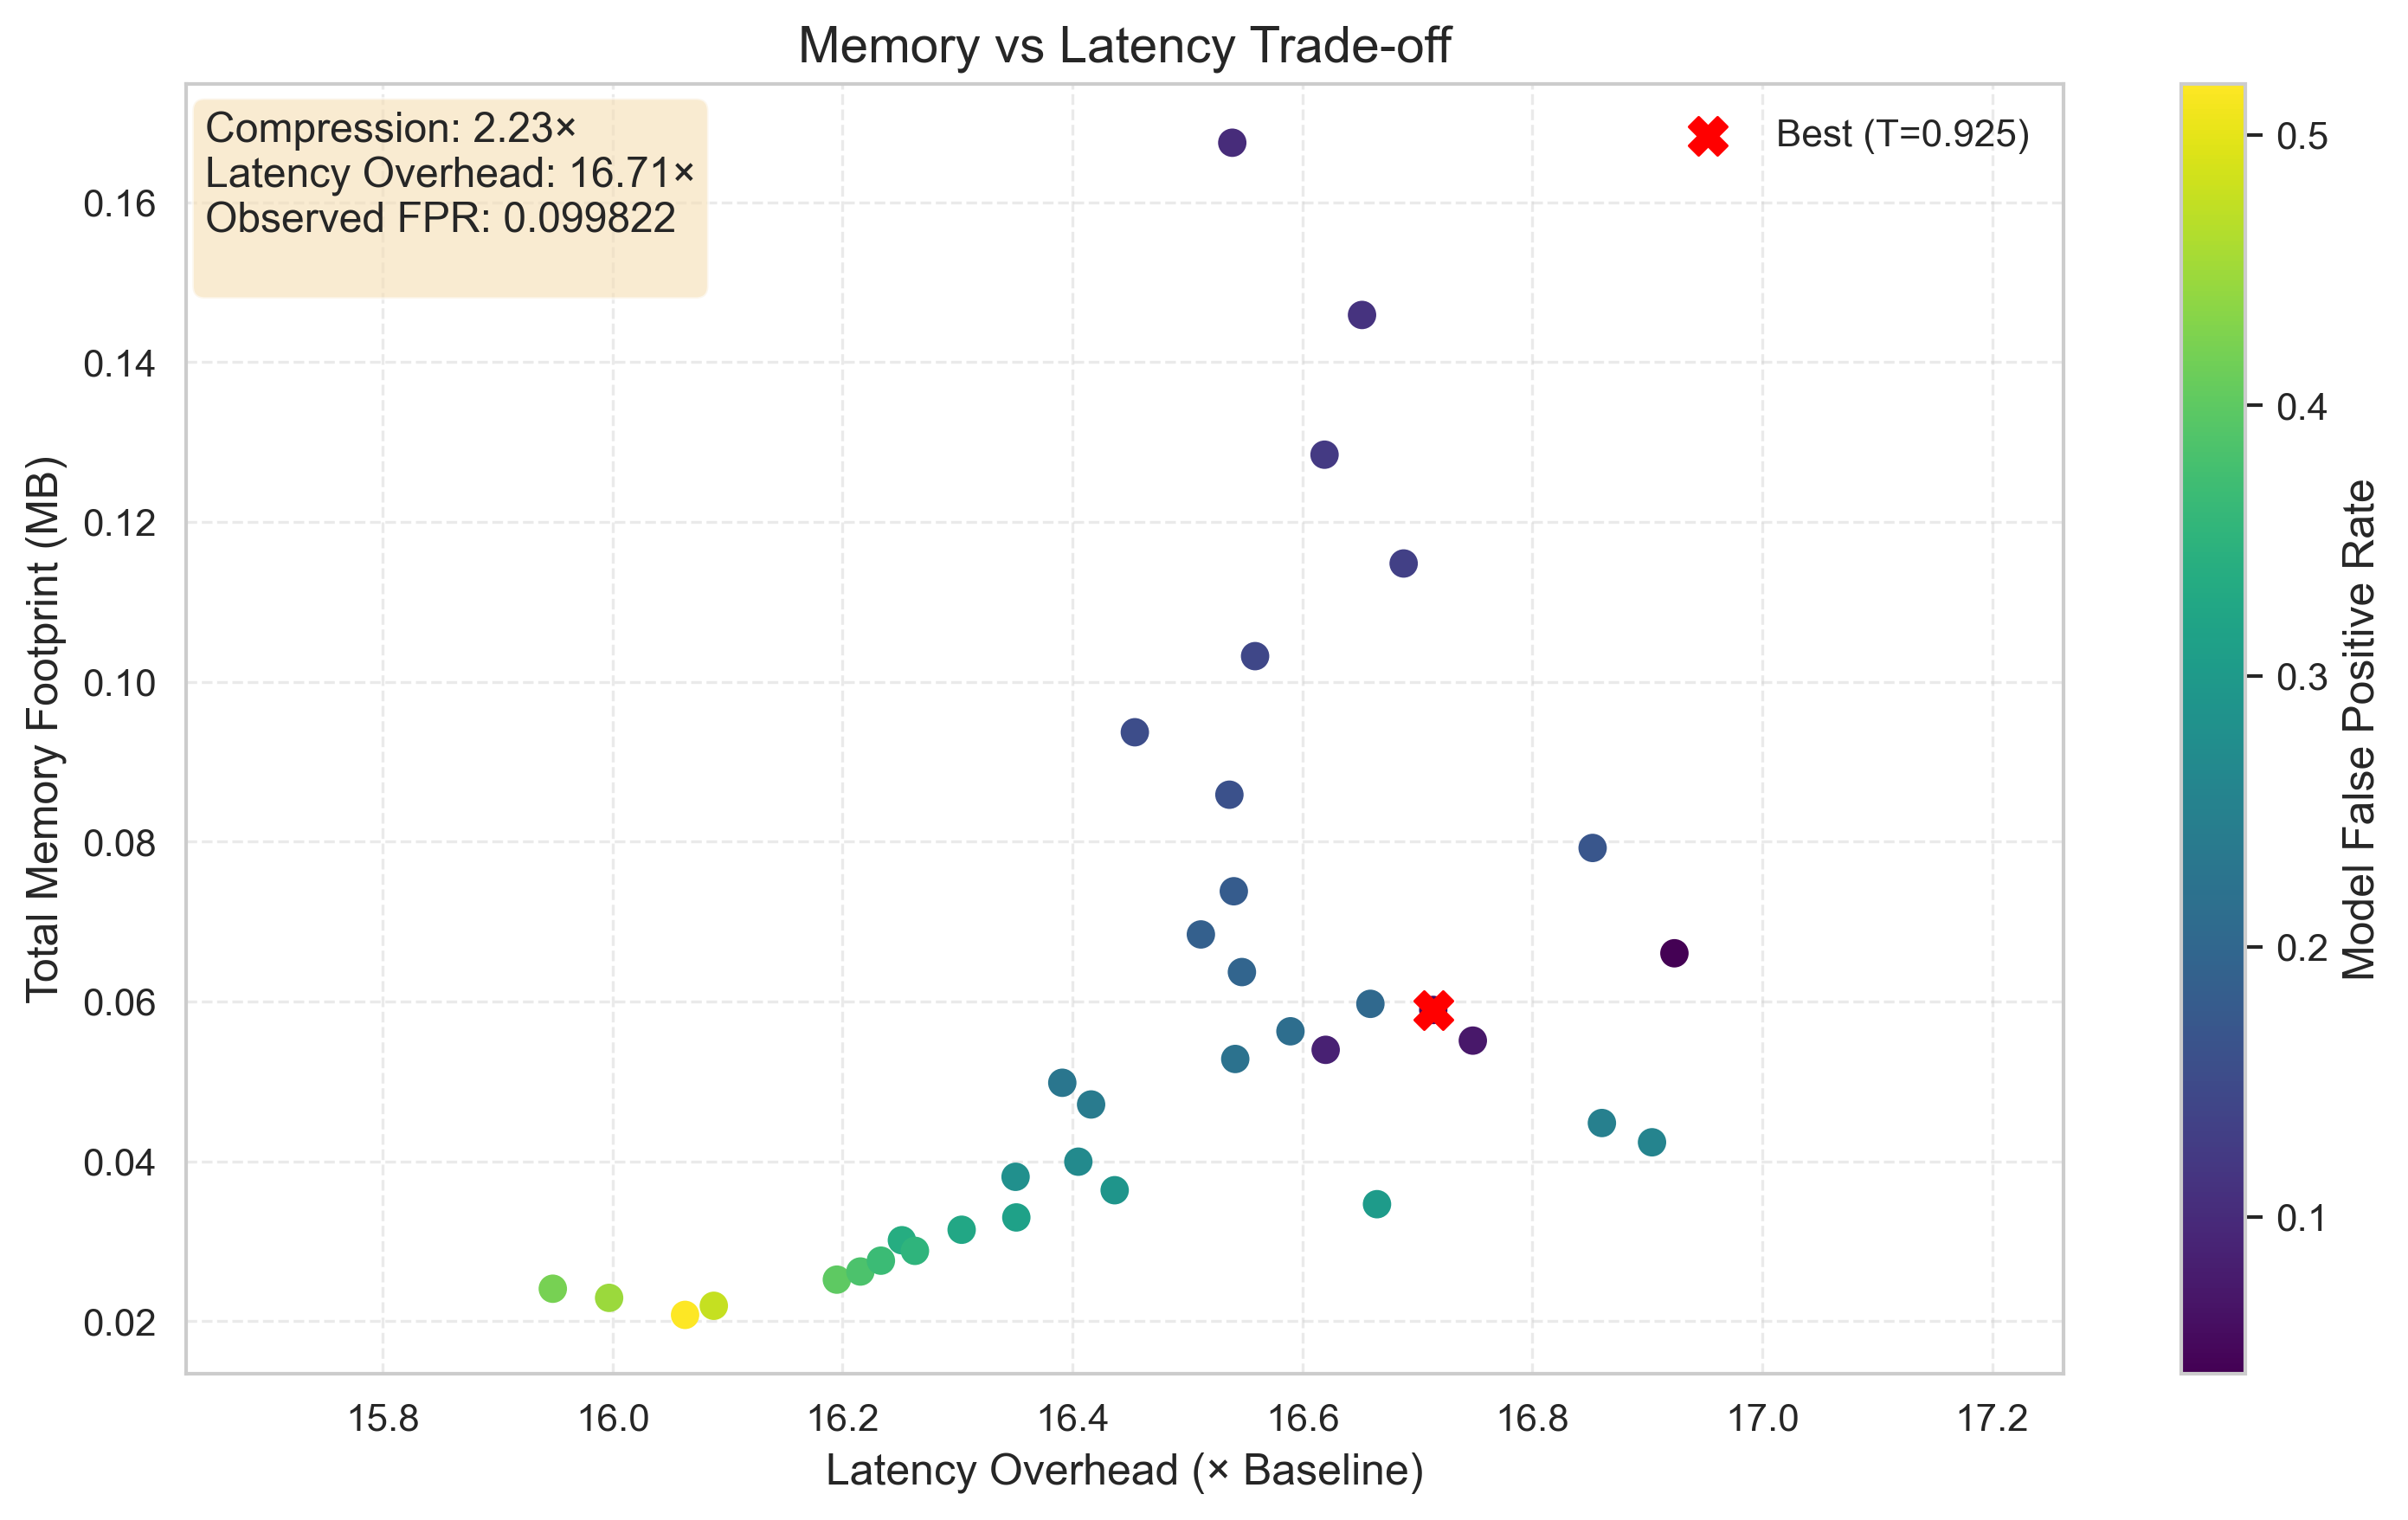

In [61]:
import matplotlib.pyplot as plt

lbf = lbf_df.sort_values("time_per_query_ns").copy()
lbf["latency_overhead"] = lbf["time_per_query_ns"] / base_latency

compression = base_memory / optimal_lbf["total_memory_mb"]
overhead = optimal_lbf["time_per_query_ns"] / base_latency

fig, ax = plt.subplots(figsize=(10,6), dpi=300)

sc = ax.scatter(
    lbf["latency_overhead"],
    lbf["total_memory_mb"],
    c=lbf["model_fp_rate"],
    cmap="viridis",
    s=50
)

ax.scatter(
    overhead,
    optimal_lbf["total_memory_mb"],
    color="red",
    marker="X",
    s=110,
    zorder=2,
    label=f'Best (T={optimal_lbf["threshold"]:.3f})'
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Model False Positive Rate")

ax.set(
    title="Memory vs Latency Trade-off",
    xlabel="Latency Overhead (× Baseline)",
    ylabel="Total Memory Footprint (MB)"
)

ax.set_xlim(
    lbf["latency_overhead"].min()*0.98,
    lbf["latency_overhead"].max()*1.02
)

ax.grid(True, ls="--", alpha=0.4)

ax.text(
    0.01, 0.85,
    f'Compression: {compression:.2f}×\n'
    f'Latency Overhead: {overhead:.2f}×\n'
    f'Observed FPR: {optimal_lbf["observed_fpr"]:.6f}\n',
    transform=ax.transAxes,
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.6)
)

ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig(f'visuals/memory_latency_FPR_Threshold.png_{TARGET_FPR}_{N_FEATURES}.png', dpi=300)
plt.show()

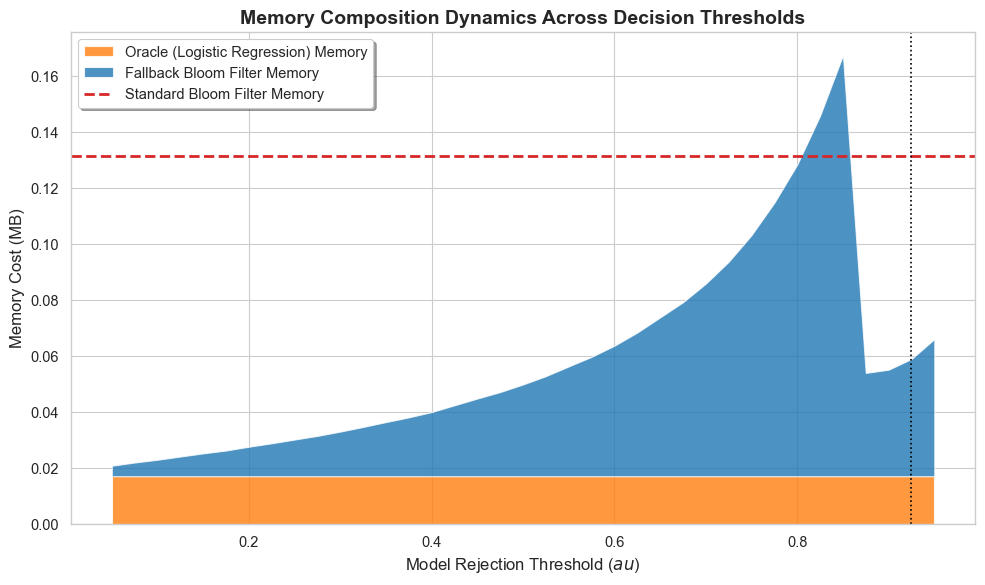

In [62]:
fig, ax = plt.subplots(figsize=(10, 6))

# Sort by threshold for the x-axis
lbf_thresh = lbf_df.sort_values('threshold')

x = lbf_thresh['threshold']
y1 = lbf_thresh['model_memory_mb']
y2 = lbf_thresh['backup_memory_mb']

# Stack plot
ax.stackplot(x, y1, y2, labels=['Oracle (Logistic Regression) Memory', 'Fallback Bloom Filter Memory'],
             colors=['#ff7f0e', '#1f77b4'], alpha=0.8)

# Add baseline reference line
ax.axhline(base_memory, color='#d62728', linestyle='--', linewidth=2, label='Standard Bloom Filter Memory')

ax.set_title('Memory Composition Dynamics Across Decision Thresholds', fontweight='bold')
ax.set_xlabel('Model Rejection Threshold ($\tau$)')
ax.set_ylabel('Memory Cost (MB)')
ax.legend(loc='upper left', frameon=True, shadow=True)

# Highlight the sweet spot
ax.axvline(optimal_lbf['threshold'], color='black', linestyle=':', label='Optimal $\tau$')

plt.tight_layout()
plt.savefig(f'visuals/memory_composition.png_{TARGET_FPR}_{N_FEATURES}.png', dpi=300)
plt.show()

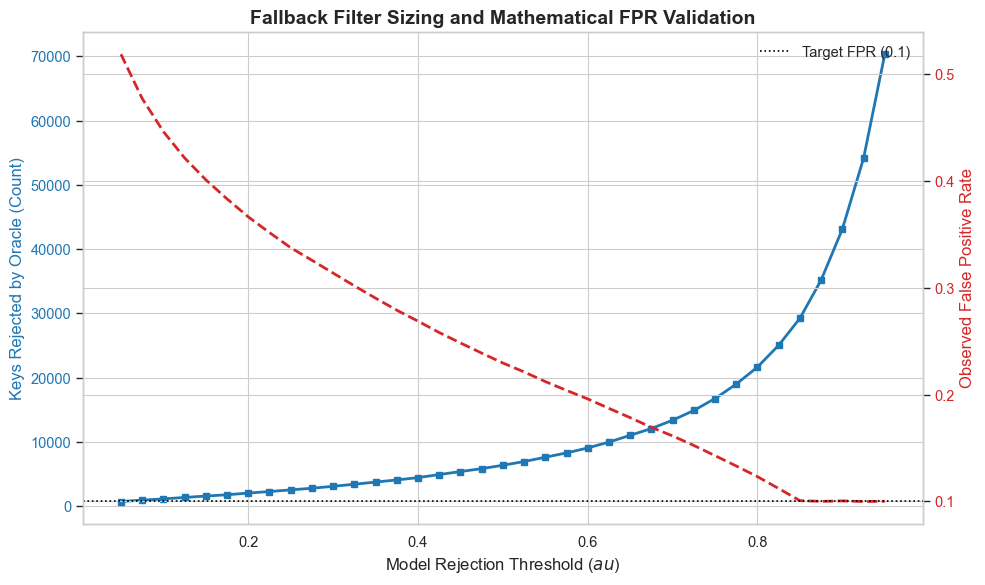

In [63]:
fig, ax1 = plt.subplots(figsize=(10, 6))

x = lbf_thresh['threshold']

# Axis 1: Items pushed to backup filter
color = '#1f77b4'
ax1.set_xlabel('Model Rejection Threshold ($\tau$)')
ax1.set_ylabel('Keys Rejected by Oracle (Count)', color=color)
ax1.plot(x, lbf_thresh['backup_key_count'], color=color, linewidth=2, marker='s', markersize=4)
ax1.tick_params(axis='y', labelcolor=color)

# Axis 2: Observed FPR
ax2 = ax1.twinx()  
color = '#d62728'
ax2.set_ylabel('Observed False Positive Rate', color=color)  
ax2.plot(x, lbf_thresh['observed_fpr'], color=color, linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

# Add Target FPR reference line
ax2.axhline(TARGET_FPR, color='black', linestyle=':', label=f'Target FPR ({TARGET_FPR})')
ax2.legend(loc='upper right')

plt.title('Fallback Filter Sizing and Mathematical FPR Validation', fontweight='bold')
plt.tight_layout()
plt.savefig(f'visuals/fpr_validation_{TARGET_FPR}_{N_FEATURES}.png', dpi=300)
plt.show()